In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [14]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\nationalDistribution.csv') 
print(set(df['Nationality']))

{'Spain', 'United Kingdom of Great Britain and Northern Ireland (the)', 'Lithuania', 'Italy', 'Other countries (2)', 'Ukraine', 'Brazil', 'Romania', 'Ireland', 'India', 'Poland'}


In [75]:
country = "Romania"
filtered_df = df[df['Nationality']==country]
print(filtered_df)

                 Statistic Label  Year Nationality          Age Group UNIT  \
24  Distributions of Employments  2023     Romania      15 - 24 years    %   
25  Distributions of Employments  2023     Romania      25 - 29 years    %   
26  Distributions of Employments  2023     Romania      30 - 39 years    %   
27  Distributions of Employments  2023     Romania      40 - 49 years    %   
28  Distributions of Employments  2023     Romania      50 - 59 years    %   
29  Distributions of Employments  2023     Romania  60 years and over    %   

    VALUE  
24   11.8  
25   12.7  
26   34.6  
27   26.8  
28   11.9  
29    2.1  


In [76]:
filtered_df['Age Group'] = filtered_df['Age Group'].apply(lambda x: " ".join(x.split(" ")[:3]))

C:\Users\Tom\AppData\Local\Temp\ipykernel_25388\4126464677.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Age Group'] = filtered_df['Age Group'].apply(lambda x: " ".join(x.split(" ")[:3]))


In [77]:
def switchC(country):
    switch = {
        "Ireland": "Irish",
        "India": "Indian",
        "Brazil": "Brazilian",
        "Romania": "Romanian",
        "Poland": "Polish"
    }
    if country not in switch:
        return country 
    else:
        return switch[country]
nat = switchC(country)

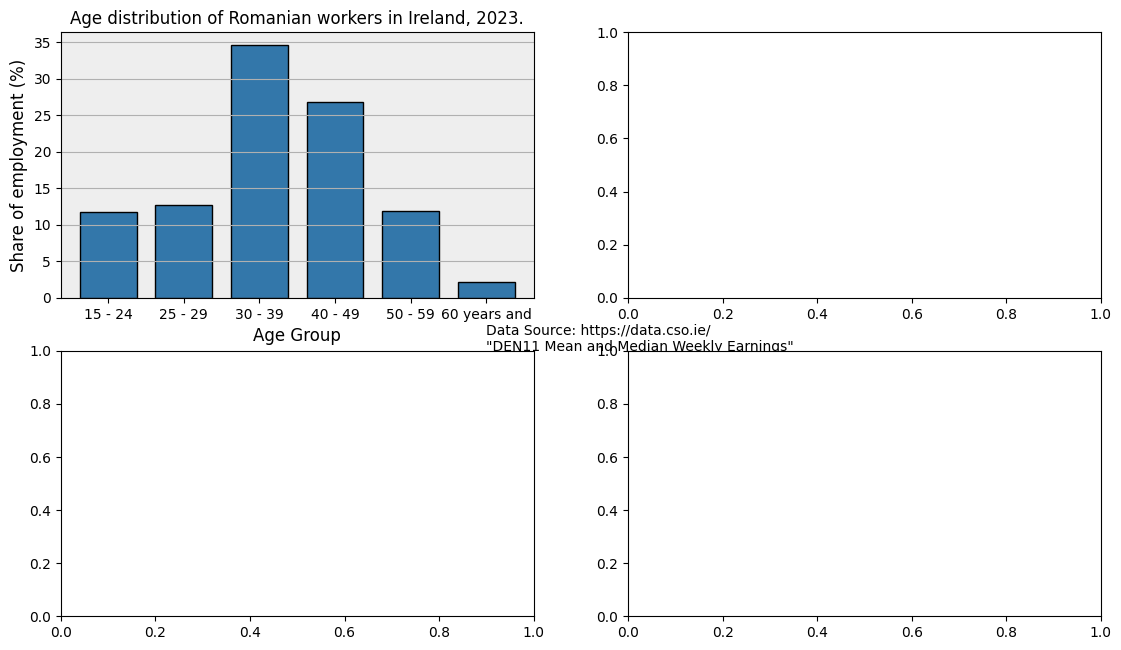

In [78]:
def draw(nat, coords): 
    fig, axs = plt.subplots(2, 2, figsize=(13, 8))

    filtered_df.plot(x="Age Group", y="VALUE", kind="bar", width=0.75, edgecolor="black", color="#3377AA", ax=axs[0,0])

    title_string = "Age distribution of "+nat+" workers in Ireland, 2023." 

    axs[0,0].set_title(title_string)
    axs[0,0].set_xlabel('Age Group', fontsize=12)
    axs[0,0].set_ylabel('Share of employment (%)', fontsize=12)
    axs[0,0].tick_params(axis='x', rotation=0)
    #ax.set_xlim(200,550)
    axs[0,0].set_facecolor('#EEEEEE') 
    axs[0,0].get_legend().remove()
    axs[0,0].grid(True, axis="y")

    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
    axs[0,0].text(0.9, -0.2, "Data Source: https://data.cso.ie/ \n\"DEN11 Mean and Median Weekly Earnings\"", ha='left', transform=axs[0,0].transAxes)

    #save_fig = 'NationalityEmploymentBreakdown'+country+'.png'
    plt.savefig(save_fig)

# Show the plot
plt.show()


In [63]:
s = "15 - 24 years"
l = s.split(" ")
st = " ".join(l[:3])
print(st)

15 - 24
